# 🦙 Alpaca vs Not-Alpaca Classification — PyTorch + ResNet50

**Objective:** Binary image classification using the Golden Rules progression — from a sanity check with a simple MLP all the way to fine-tuned transfer learning with ResNet50.

**Golden Rules Roadmap:**
1. **Sanity Check** — Few data, Simple model (verify code works)
2. **Establish a Baseline** — Full training data, Simple model (MLP)
3. **Reduce Bias (Fix Underfitting)** — Full training data, Complex model (CNN)
4. **Reduce Variance (Fix Overfitting)** — Full training data, Complex model + Regularization
5. **Transfer Learning with ResNet50** — Pretrained features

**Dataset Domain:** Natural images of alpacas and non-alpacas (animals/objects). 
**Model Domain (ImageNet):** ResNet50 was pretrained on ImageNet which contains 1000 classes including various animals, objects, and scenes. Since our alpaca images are natural photos very similar to ImageNet's domain (animals in natural settings), the pretrained features should transfer very well. If this were a medical imaging or satellite task, the domain gap would be much larger and we'd need more fine-tuning.

In [34]:
# ============================================================
# Required Libraries
# We use PyTorch for everything: model, data loading, training
# Lazy loading is done naturally via ImageFolder + DataLoader
# (the images are loaded on-the-fly per batch, not all into RAM at once)
# da el tare2a el a7san 3ashan el RAM maynfegar4 lw el dataset kbera
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import json
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [35]:
# ============================================================
# Data Transforms & Lazy Loading Setup
# ImageFolder + DataLoader = Lazy Loading by default
# Each batch is loaded from disk on demand, not preloaded into memory
# kda el sowar btet7emel wa7da wa7da mesh kolaha mara wa7da, da ely esmoh lazy loading
# ============================================================

IMG_SIZE = 160
BATCH_SIZE = 32

# Training transforms: resize, augment, normalize to ImageNet stats
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation transforms: just resize + normalize, no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ============================================================
# Load dataset using ImageFolder (lazy loading)
# ImageFolder expects: root/class_name/image.jpg structure
# el data loader hena bey2ra el sowar mn el disk lamma beyegy dor el batch bta3ha bs
# ============================================================

data_dir = "/kaggle/input/datasets/sid4sal/alpaca-dataset-small/dataset"

full_dataset = datasets.ImageFolder(data_dir)
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Total images: {len(full_dataset)}")

# Manual train/val split (80/20)
from torch.utils.data import random_split
torch.manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# Apply different transforms by wrapping
class TransformedSubset(torch.utils.data.Dataset):
    """Wraps a Subset so we can apply a custom transform (lazy loaded per __getitem__ call)"""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = TransformedSubset(train_subset, train_transform)
val_dataset = TransformedSubset(val_subset, val_transform)

# DataLoader: this is where lazy loading actually happens
# num_workers > 0 means parallel loading in background threads
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train set: {len(train_dataset)} images")
print(f"Val set: {len(val_dataset)} images")
print(f"Batches per epoch (train): {len(train_loader)}, (val): {len(val_loader)}")

Classes: ['alpaca', 'not alpaca']
Total images: 327
Train set: 261 images
Val set: 66 images
Batches per epoch (train): 9, (val): 3


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


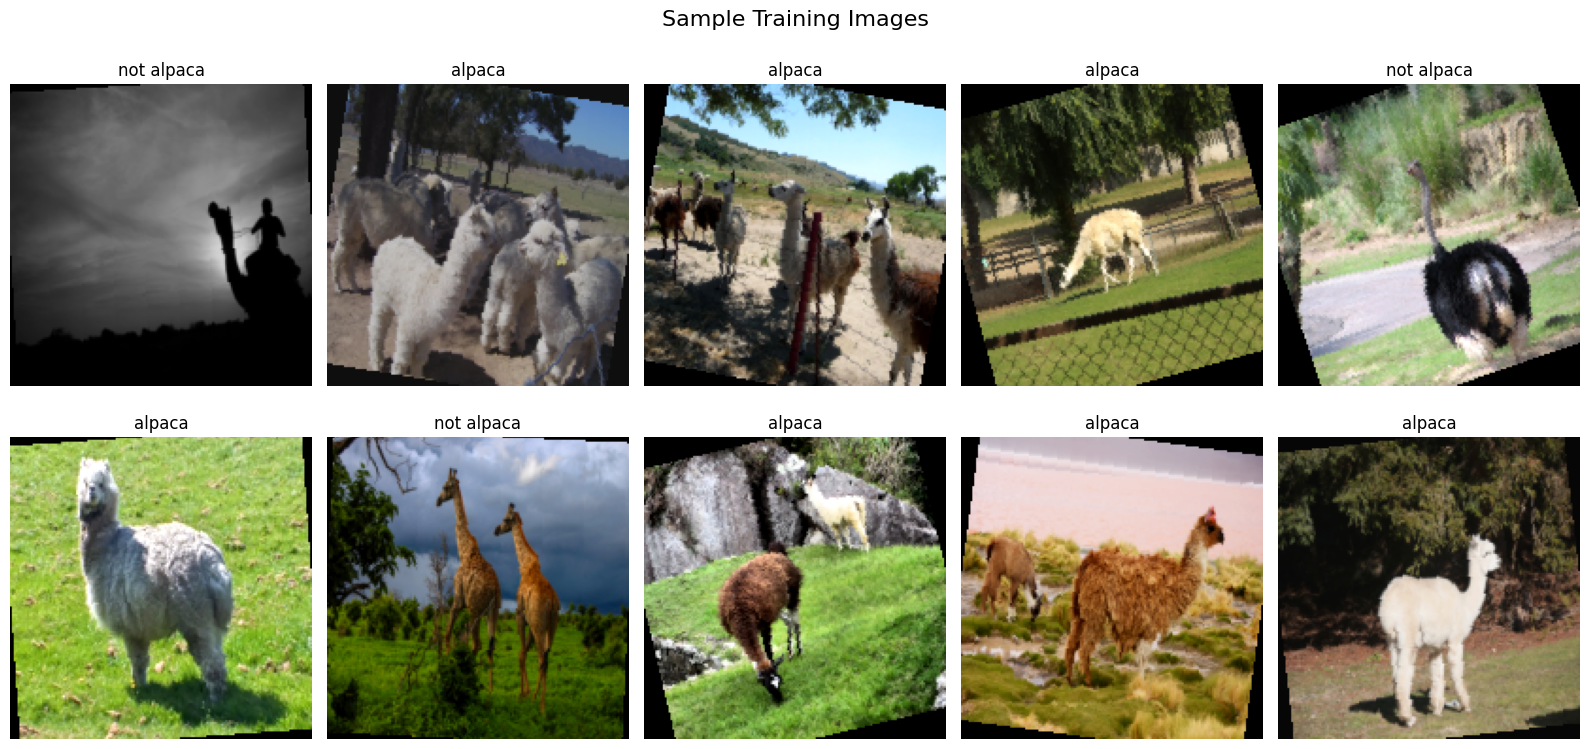

In [36]:
# ============================================================
# Visualize some samples from the training set
# We denormalize so images look correct when plotted
# lazem ne3mel denormalize 3ashan el sowar tban sa7 mesh ghame2
# ============================================================

def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Undo ImageNet normalization for display"""
    t = tensor.clone()
    for i in range(3):
        t[i] = t[i] * std[i] + mean[i]
    return torch.clamp(t, 0, 1)

images, labels = next(iter(train_loader))
plt.figure(figsize=(16, 8))
for i in range(min(10, len(images))):
    ax = plt.subplot(2, 5, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(class_names[labels[i]], fontsize=12)
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

# ⚙️ Shared Training & Evaluation Utilities

We define a reusable training loop and evaluation function that we'll use across ALL experiments. This avoids code duplication and ensures consistent metrics tracking.

In [37]:
# ============================================================
# Shared Training Loop & Evaluation Functions
# Used by ALL models so we get consistent metrics everywhere
# kol el models hayesta5dmoo nafs el function di 3ashan el results tkon moqa4rana sa7
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy().astype(int))
    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return epoch_loss, acc, rec, prec, f1

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy().astype(int))
    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return epoch_loss, acc, rec, prec, f1

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, model_name="Model"):
    """Full training loop with history tracking"""
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": [],
               "train_recall": [], "val_recall": [],
               "train_precision": [], "val_precision": [],
               "train_f1": [], "val_f1": []}
    
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(epochs):
        tr_loss, tr_acc, tr_rec, tr_prec, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, vl_rec, vl_prec, vl_f1 = evaluate(model, val_loader, criterion, device)
        
        history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc); history["val_acc"].append(vl_acc)
        history["train_recall"].append(tr_rec); history["val_recall"].append(vl_rec)
        history["train_precision"].append(tr_prec); history["val_precision"].append(vl_prec)
        history["train_f1"].append(tr_f1); history["val_f1"].append(vl_f1)
        
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_model_wts = copy.deepcopy(model.state_dict())
        
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} Recall: {vl_rec:.4f} F1: {vl_f1:.4f}")
    
    model.load_state_dict(best_model_wts)
    return history

def plot_history(history, title="Training History"):
    """Plot loss and accuracy curves for train and val"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")
    
    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")
    
    axes[2].plot(history["train_recall"], label="Train Recall")
    axes[2].plot(history["val_recall"], label="Val Recall")
    axes[2].plot(history["train_f1"], label="Train F1")
    axes[2].plot(history["val_f1"], label="Val F1")
    axes[2].set_title("Recall & F1"); axes[2].legend(); axes[2].set_xlabel("Epoch")
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Golden Rule Step 1 — Sanity Check (Code Verification)
**Few data + Simple model (MLP)**

The goal here is NOT to get good accuracy. We just want to verify our code pipeline works end-to-end: data loading → model forward pass → loss computation → backprop → evaluation. We use a tiny subset of the data and a basic MLP.

If the model can overfit a tiny batch, the code is correct. If loss doesn't decrease at all, something is broken.

In [38]:
# ============================================================
# GOLDEN RULE 1: Sanity Check — Few data, Simple MLP
# We take a tiny subset (just 1 batch!) and try to overfit it
# The point is to make sure our code actually works before wasting hours
# el hadaf hena en e7na net2aked en el code sha3'al mesh aktar, lw el loss neze da kwayes
# ============================================================

class SimpleMLP(nn.Module):
    """Basic MLP that flattens the image and passes through dense layers.
    This is terrible for images but that's the point — we're just sanity checking."""
    def __init__(self, input_size=IMG_SIZE*IMG_SIZE*3, hidden=256, num_classes=1):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(input_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

# Take a TINY subset for sanity check — just 32 samples
sanity_subset_train = Subset(train_dataset, range(min(32, len(train_dataset))))
sanity_subset_val = Subset(val_dataset, range(min(16, len(val_dataset))))
sanity_train_loader = DataLoader(sanity_subset_train, batch_size=16, shuffle=True)
sanity_val_loader = DataLoader(sanity_subset_val, batch_size=16, shuffle=False)

mlp_sanity = SimpleMLP().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer_sanity = optim.Adam(mlp_sanity.parameters(), lr=1e-3)

print("=== Sanity Check: MLP on tiny data ===")
print(f"Parameters: {sum(p.numel() for p in mlp_sanity.parameters()):,}")
history_sanity = train_model(mlp_sanity, sanity_train_loader, sanity_val_loader,
                             criterion, optimizer_sanity, device, epochs=10, model_name="MLP-Sanity")

=== Sanity Check: MLP on tiny data ===
Parameters: 19,677,569
[MLP-Sanity] Epoch 1/10 | Train Loss: 3.4659 Acc: 0.3750 | Val Loss: 1.2563 Acc: 0.7500 Recall: 0.6667 F1: 0.6667
[MLP-Sanity] Epoch 2/10 | Train Loss: 2.0792 Acc: 0.5938 | Val Loss: 2.1645 Acc: 0.2500 Recall: 0.6667 F1: 0.4000
[MLP-Sanity] Epoch 3/10 | Train Loss: 1.8799 Acc: 0.6562 | Val Loss: 3.3470 Acc: 0.3125 Recall: 0.8333 F1: 0.4762
[MLP-Sanity] Epoch 4/10 | Train Loss: 0.8082 Acc: 0.6875 | Val Loss: 3.5177 Acc: 0.5000 Recall: 0.6667 F1: 0.5000
[MLP-Sanity] Epoch 5/10 | Train Loss: 0.3806 Acc: 0.8750 | Val Loss: 4.3913 Acc: 0.3750 Recall: 0.5000 F1: 0.3750
[MLP-Sanity] Epoch 6/10 | Train Loss: 0.5379 Acc: 0.8438 | Val Loss: 5.7284 Acc: 0.3125 Recall: 0.8333 F1: 0.4762
[MLP-Sanity] Epoch 7/10 | Train Loss: 1.2406 Acc: 0.7812 | Val Loss: 6.5377 Acc: 0.3125 Recall: 0.8333 F1: 0.4762
[MLP-Sanity] Epoch 8/10 | Train Loss: 1.6984 Acc: 0.7812 | Val Loss: 6.4978 Acc: 0.4375 Recall: 0.6667 F1: 0.4706
[MLP-Sanity] Epoch 9/10 | 

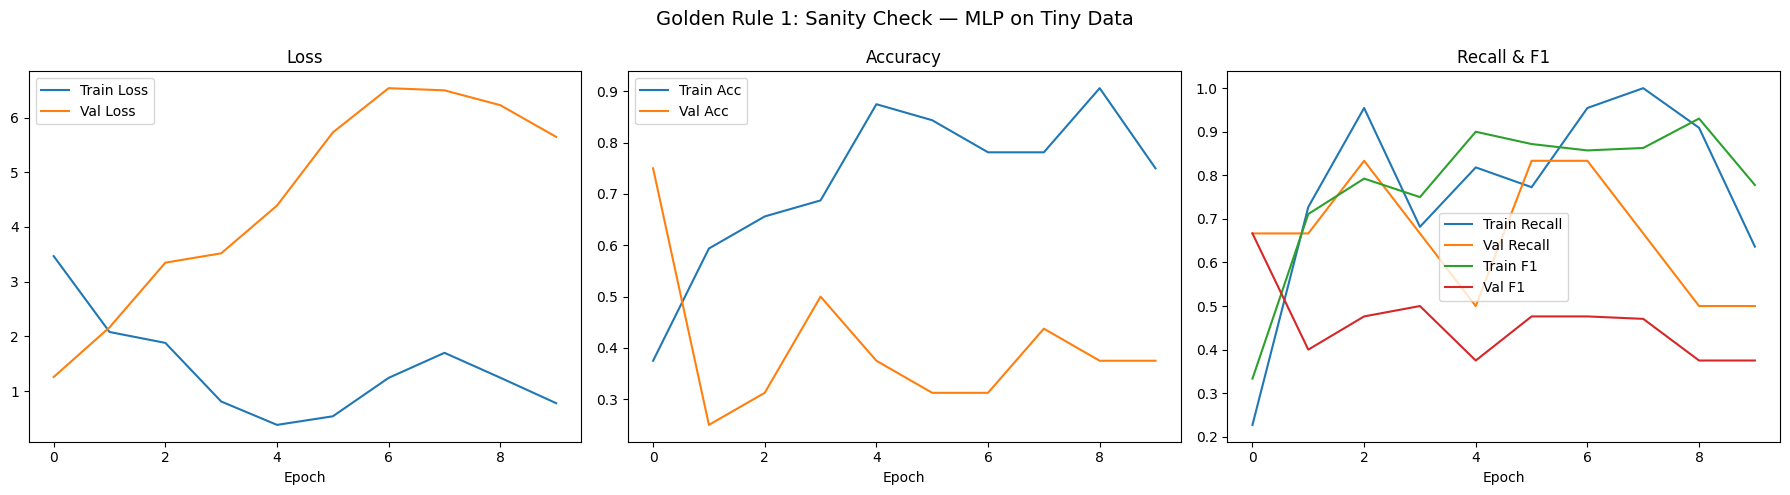


✅ COMMENT: The sanity check verifies our training pipeline is functional.
Loss should decrease on this tiny set. Accuracy doesn't matter yet — we used
a trivial MLP on just 32 images. The model likely memorizes this tiny batch,
which is exactly what we want to see (proves backprop is working).
lw el loss nzel we el accuracy tl3et f3lan, yb2a e7na tamam we momken nekamel


In [39]:
# ============================================================
# Sanity Check Results
# If training loss went down, great — our pipeline works
# lw el loss 2al, yb2a el code sha3'al, momken el accuracy mesh 7elwa bs da 3ady delwa2ty
# ============================================================

plot_history(history_sanity, "Golden Rule 1: Sanity Check — MLP on Tiny Data")
print("\n✅ COMMENT: The sanity check verifies our training pipeline is functional.")
print("Loss should decrease on this tiny set. Accuracy doesn't matter yet — we used")
print("a trivial MLP on just 32 images. The model likely memorizes this tiny batch,")
print("which is exactly what we want to see (proves backprop is working).")
print("lw el loss nzel we el accuracy tl3et f3lan, yb2a e7na tamam we momken nekamel")

# 🥈 Golden Rule Step 2 — Establish a Baseline (Good Enough)
**Full training data + Simple model (MLP)**

Now we use the FULL dataset but still with the simple MLP. This gives us a baseline to compare against. An MLP treats pixels as independent features — it can't understand spatial patterns, edges, or textures. We expect mediocre accuracy but it sets the floor for what "no spatial reasoning" looks like.

# ============================================================
# GOLDEN RULE 2: Baseline — Full data, Simple MLP
# Same MLP architecture, but now on ALL training data
# hena benshoof el MLP el baseet da yedeny kam accuracy 3ala kol el data
# da el ard ely hane2ees 3aleih — ay 7aga a7san men kda yb2a e7na bnet7asen
# ============================================================


In [40]:
mlp_baseline = SimpleMLP().to(device)
optimizer_baseline = optim.Adam(mlp_baseline.parameters(), lr=1e-3)

print("=== Baseline: MLP on Full Training Data ===")
print(f"Parameters: {sum(p.numel() for p in mlp_baseline.parameters()):,}")
history_baseline = train_model(mlp_baseline, train_loader, val_loader,
                               criterion, optimizer_baseline, device, epochs=10, model_name="MLP-Baseline")

=== Baseline: MLP on Full Training Data ===
Parameters: 19,677,569


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[MLP-Baseline] Epoch 1/10 | Train Loss: 3.0934 Acc: 0.5441 | Val Loss: 2.1660 Acc: 0.6667 Recall: 0.6667 F1: 0.6857


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[MLP-Baseline] Epoch 2/10 | Train Loss: 2.5276 Acc: 0.4943 | Val Loss: 2.6323 Acc: 0.5152 Recall: 0.7500 F1: 0.6279


...

[MLP-Baseline] Epoch 8/10 | Train Loss: 0.7803 Acc: 0.6705 | Val Loss: 1.2507 Acc: 0.6970 Recall: 0.8056 F1: 0.7436


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[MLP-Baseline] Epoch 9/10 | Train Loss: 0.6802 Acc: 0.6705 | Val Loss: 1.6365 Acc: 0.6364 Recall: 0.8611 F1: 0.7209


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[MLP-Baseline] Epoch 10/10 | Train Loss: 0.5199 Acc: 0.8008 | Val Loss: 1.4018 Acc: 0.6818 Recall: 0.8889 F1: 0.7529


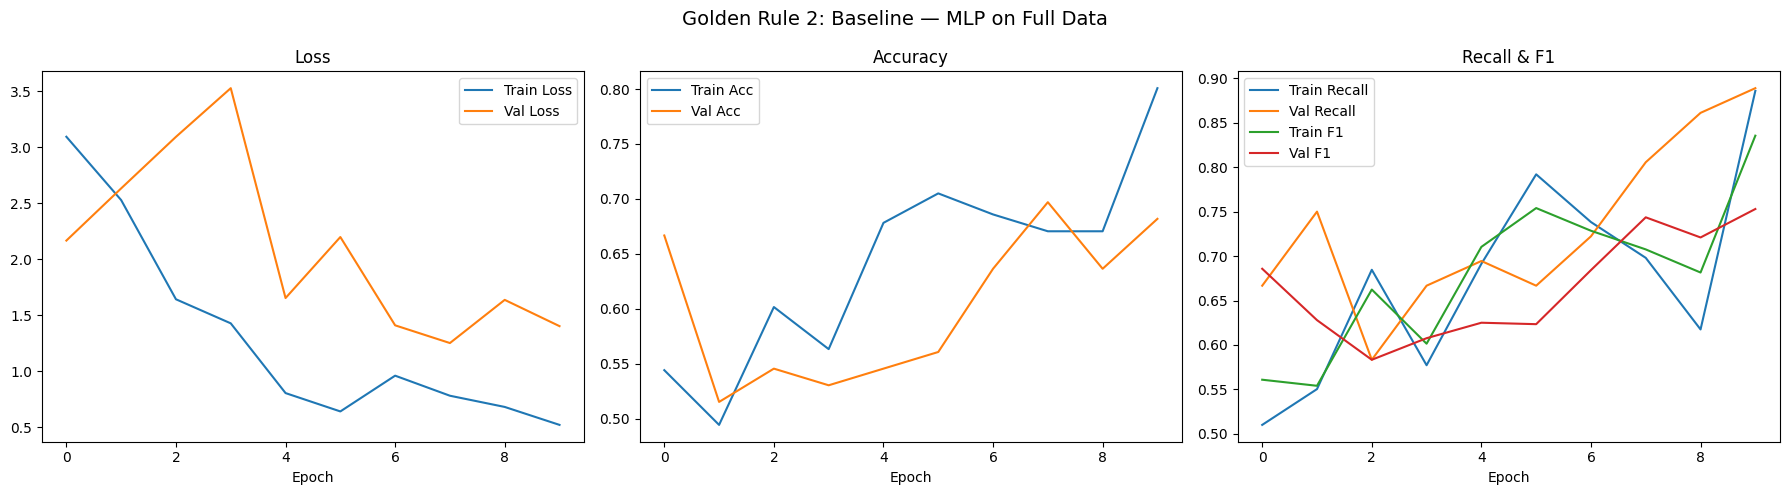


 COMMENT: The baseline MLP performance is our reference point.
MLPs flatten the image into a 1D vector, destroying spatial relationships.
For 160x160x3 images, the MLP has 76,800 input features per image — huge and wasteful.
We expect accuracy around 50-65% (barely better than random for binary classification).
This proves we NEED spatial feature extraction → time to move to CNNs.
el MLP da mesh fahem en fi alpaca wala la2, howa bs shaghalen 3ala argam flat


In [41]:
# ============================================================
# Baseline MLP Results
# We expect low-to-mediocre accuracy — MLPs fail on images because they
# treat each pixel independently, losing all spatial information
# el MLP mesh fاhem 7aga f el sowar — howa shayfha argam 3ashwa2eya gedan
# ============================================================

plot_history(history_baseline, "Golden Rule 2: Baseline — MLP on Full Data")
print("\n COMMENT: The baseline MLP performance is our reference point.")
print("MLPs flatten the image into a 1D vector, destroying spatial relationships.")
print("For 160x160x3 images, the MLP has 76,800 input features per image — huge and wasteful.")
print("We expect accuracy around 50-65% (barely better than random for binary classification).")
print("This proves we NEED spatial feature extraction → time to move to CNNs.")
print("el MLP da mesh fahem en fi alpaca wala la2, howa bs shaghalen 3ala argam flat")

# 🥉 Golden Rule Step 3 — Reduce Bias (Fix Underfitting)
**Full training data + Complex model (CNN)**

The MLP was underfitting because it couldn't learn spatial patterns. A CNN uses convolutional filters that slide over the image, detecting edges, textures, and shapes. This is a much better inductive bias for images. We expect a significant jump in accuracy here.

In [42]:
# ============================================================
# GOLDEN RULE 3: Reduce Bias — CNN (Complex model, no regularization yet)
# CNNs use convolution filters that understand spatial patterns
# da el model ely ha yefham en el sowar feha shapes we edges, mesh bs argam
# ============================================================

class SimpleCNN(nn.Module):
    """A basic CNN without any regularization (no dropout, no batch norm).
    We want to see how much better convolutions are vs the MLP baseline."""
    def __init__(self, num_classes=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 80x80
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 40x40
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # 20x20
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))      # 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_model = SimpleCNN().to(device)
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=1e-3)

print("=== Reduce Bias: CNN on Full Training Data ===")
print(f"Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
history_cnn = train_model(cnn_model, train_loader, val_loader,
                          criterion, optimizer_cnn, device, epochs=15, model_name="CNN-NoBN")

=== Reduce Bias: CNN on Full Training Data ===
Parameters: 404,929


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-NoBN] Epoch 1/15 | Train Loss: 0.7112 Acc: 0.4981 | Val Loss: 0.6836 Acc: 0.5455 Recall: 1.0000 F1: 0.7059


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-NoBN] Epoch 2/15 | Train Loss: 0.6858 Acc: 0.5709 | Val Loss: 0.6911 Acc: 0.5758 Recall: 0.9444 F1: 0.7083


...

[CNN-NoBN] Epoch 13/15 | Train Loss: 0.6850 Acc: 0.5709 | Val Loss: 0.6719 Acc: 0.5455 Recall: 1.0000 F1: 0.7059


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-NoBN] Epoch 14/15 | Train Loss: 0.6746 Acc: 0.5709 | Val Loss: 0.6771 Acc: 0.5303 Recall: 0.9722 F1: 0.6931


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-NoBN] Epoch 15/15 | Train Loss: 0.6705 Acc: 0.5709 | Val Loss: 0.6725 Acc: 0.5455 Recall: 1.0000 F1: 0.7059


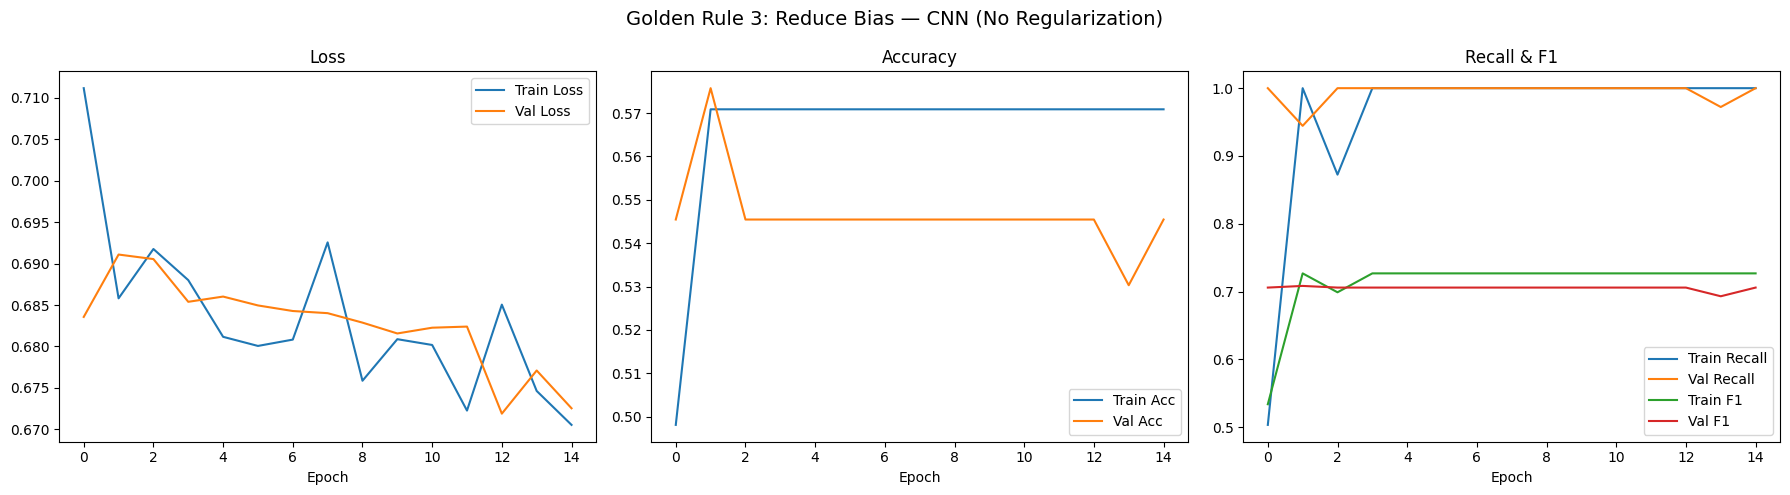


📊 COMMENT: The CNN should significantly outperform the MLP baseline.
Convolutional layers detect local patterns (edges, textures, shapes) that are
invariant to position — exactly what we need for image classification.
HOWEVER, without any regularization (no dropout, no batch norm), the model
might overfit: high training accuracy but lower validation accuracy.
This gap between train/val metrics = OVERFITTING → we need regularization next.
el CNN a7san beketeer mn el MLP bs fe far2 bein el train w el val, y3ny overfit shwaya


In [43]:
# ============================================================
# CNN without regularization Results
# We should see much better training accuracy but probably a gap with val accuracy
# ya3ny el model byet3alem kwayes bs momken ye3mel overfit, 3ashan mafish regularization
# ============================================================

plot_history(history_cnn, "Golden Rule 3: Reduce Bias — CNN (No Regularization)")
print("\n📊 COMMENT: The CNN should significantly outperform the MLP baseline.")
print("Convolutional layers detect local patterns (edges, textures, shapes) that are")
print("invariant to position — exactly what we need for image classification.")
print("HOWEVER, without any regularization (no dropout, no batch norm), the model")
print("might overfit: high training accuracy but lower validation accuracy.")
print("This gap between train/val metrics = OVERFITTING → we need regularization next.")
print("el CNN a7san beketeer mn el MLP bs fe far2 bein el train w el val, y3ny overfit shwaya")

# 🏆 Golden Rule Step 4 — Reduce Variance (Fix Overfitting)
**Full training data + Complex model + Regularization**

The CNN was overfitting. Now we add regularization techniques:
- **Batch Normalization** — stabilizes training, acts as mild regularization
- **Dropout** — randomly zeroes neurons during training, forces redundancy
- Data augmentation is already applied in our transforms

This should close the train/val gap while maintaining (or improving) accuracy.

In [45]:
# ============================================================
# GOLDEN RULE 4: Reduce Variance — CNN + Regularization (BatchNorm + Dropout)
# Same CNN structure but with dropout and batch normalization
# hena bene7ot dropout w batchnorm 3ashan el model mayetla3sh el data bel 7efz
# ============================================================

class RegularizedCNN(nn.Module):
    """CNN with BatchNorm + Dropout to combat overfitting.
    This is the complete model following all golden rules."""
    def __init__(self, num_classes=1, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_reg = RegularizedCNN(dropout_rate=0.3).to(device)
optimizer_cnn_reg = optim.Adam(cnn_reg.parameters(), lr=1e-3)

print("=== Reduce Variance: CNN + Regularization ===")
print(f"Parameters: {sum(p.numel() for p in cnn_reg.parameters()):,}")
history_cnn_reg = train_model(cnn_reg, train_loader, val_loader,
                              criterion, optimizer_cnn_reg, device, epochs=15, model_name="CNN-Regularized")

=== Reduce Variance: CNN + Regularization ===
Parameters: 405,889


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-Regularized] Epoch 1/15 | Train Loss: 0.6852 Acc: 0.5517 | Val Loss: 0.6877 Acc: 0.5455 Recall: 1.0000 F1: 0.7059


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-Regularized] Epoch 2/15 | Train Loss: 0.6772 Acc: 0.5900 | Val Loss: 0.6891 Acc: 0.5909 Recall: 0.8889 F1: 0.7033


...

[CNN-Regularized] Epoch 13/15 | Train Loss: 0.6243 Acc: 0.6743 | Val Loss: 0.8290 Acc: 0.5455 Recall: 0.3889 F1: 0.4828


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-Regularized] Epoch 14/15 | Train Loss: 0.6403 Acc: 0.6628 | Val Loss: 0.7159 Acc: 0.5606 Recall: 0.6389 F1: 0.6133


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[CNN-Regularized] Epoch 15/15 | Train Loss: 0.6340 Acc: 0.6705 | Val Loss: 0.7104 Acc: 0.5758 Recall: 0.5833 F1: 0.6000


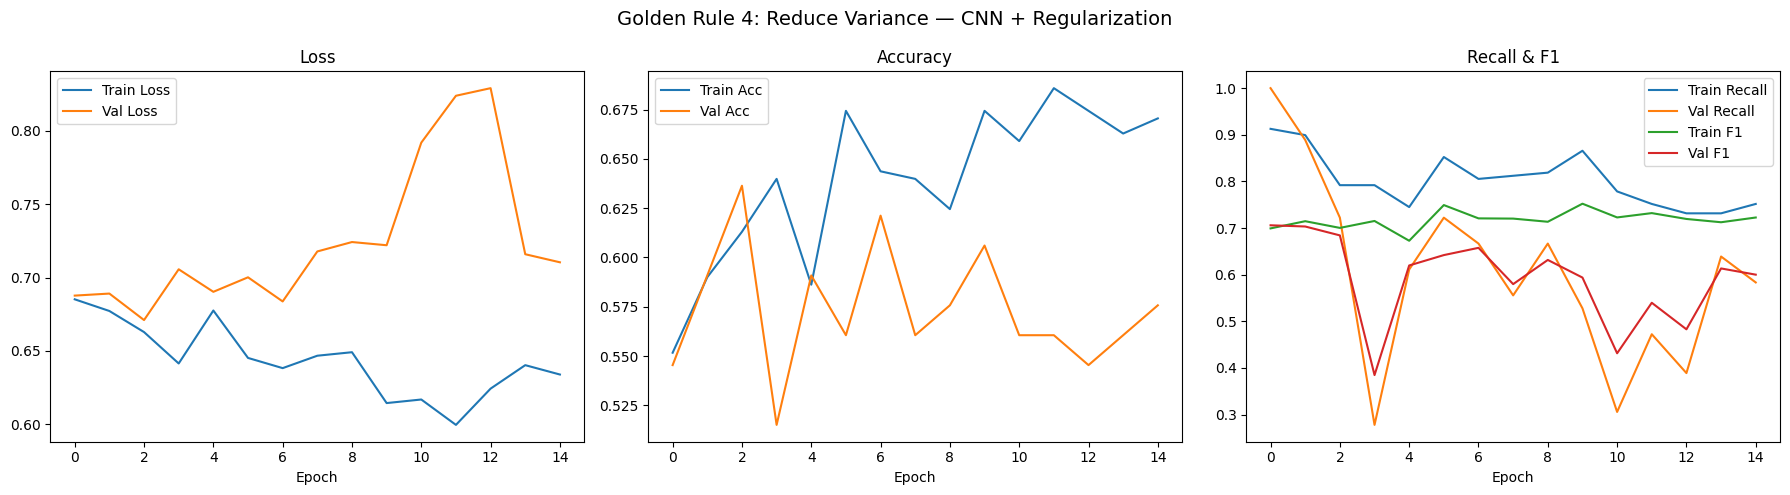


📊 COMMENT: With BatchNorm + Dropout, the train/val gap should shrink.
BatchNorm normalizes activations between layers → faster, more stable training.
Dropout randomly disables neurons → prevents co-adaptation and memorization.
Data augmentation (random flips, rotation, color jitter) also helps by showing
the model slightly different versions of each image every epoch.
If val accuracy is now closer to train accuracy → regularization is working!
el model ba2a bye-generalize a7san, mesh bs bey7afez el training data


In [46]:
# ============================================================
# Regularized CNN Results
# The gap between train and val should be smaller now
# el far2 bein el train w el val lazem ye2al — da ma3nah el dropout sha3'al
# ============================================================

plot_history(history_cnn_reg, "Golden Rule 4: Reduce Variance — CNN + Regularization")
print("\n📊 COMMENT: With BatchNorm + Dropout, the train/val gap should shrink.")
print("BatchNorm normalizes activations between layers → faster, more stable training.")
print("Dropout randomly disables neurons → prevents co-adaptation and memorization.")
print("Data augmentation (random flips, rotation, color jitter) also helps by showing")
print("the model slightly different versions of each image every epoch.")
print("If val accuracy is now closer to train accuracy → regularization is working!")
print("el model ba2a bye-generalize a7san, mesh bs bey7afez el training data")

# 🚀 Transfer Learning with ResNet50

**Why Transfer Learning?**
Our dataset is small (~300 images). Training a deep CNN from scratch on this will overfit badly. ResNet50 was trained on 1.2M ImageNet images — it already knows how to extract powerful features from natural images.

**Domain Analysis:**
- **Source domain (ImageNet):** 1000 classes of real-world objects, animals, scenes, vehicles, etc.
- **Target domain (Alpaca dataset):** Natural photos of alpacas vs other animals/objects.
- **Domain similarity: HIGH** — Both are natural photos taken with regular cameras. ImageNet even contains llama/alpaca-like categories. The low-level features (edges, textures) and mid-level features (fur patterns, body shapes) learned from ImageNet transfer directly.
- **Conclusion:** Since domains are very similar and our dataset is small, we should start by freezing most layers and only training the classifier. Fine-tuning deeper layers risks destroying good pretrained features.

## Scenarios:
- **3-A:** Freeze ALL ResNet50 layers, train only the FC classifier head
- **3-B:** Freeze early/mid layers, fine-tune final layers (high-level features)
- **3-C:** Fine-tune ALL parameters end-to-end

In [47]:
# ============================================================
# Save filters BEFORE fine-tuning for comparison later
# We grab conv1 (first conv layer) weights from the pretrained model
# da 3ashan ne2aren el filters abl we ba3d el training, ne4ouf eh ely etghayyar
# ============================================================

def get_resnet50_model(freeze_mode="all"):
    """
    Create ResNet50-based classifier with different freezing strategies.
    freeze_mode: 'all' (3-A), 'partial' (3-B), 'none' (3-C)
    """
    base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    if freeze_mode == "all":
        # 3-A: Freeze everything in backbone
        for param in base.parameters():
            param.requires_grad = False
    elif freeze_mode == "partial":
        # 3-B: Freeze everything except layer4 (final residual block)
        for param in base.parameters():
            param.requires_grad = False
        for param in base.layer4.parameters():
            param.requires_grad = True
    elif freeze_mode == "none":
        # 3-C: Everything is trainable
        pass
    
    # Replace the final FC layer for binary classification
    num_ftrs = base.fc.in_features
    base.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 1)
    )
    return base

# Save PRETRAINED filters before any fine-tuning
pretrained_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
filters_before = pretrained_resnet.conv1.weight.data.clone().cpu()
print(f"Saved pretrained conv1 filters shape: {filters_before.shape}")
print("These are the 7x7 filters from the very first layer of ResNet50")
print("kan lazem ne7ot el filters abl ma ne3mel training 3ashan ne2aren ba3dein")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s] 


Saved pretrained conv1 filters shape: torch.Size([64, 3, 7, 7])
These are the 7x7 filters from the very first layer of ResNet50
kan lazem ne7ot el filters abl ma ne3mel training 3ashan ne2aren ba3dein


# 📌 3-A: Transfer Learning — Just Classification FC Layers
Freeze ALL ResNet50 backbone layers. Only the new FC head is trained. This is the fastest approach and works well when the source and target domains are similar (which they are here — both natural images).

In [48]:
# ============================================================
# 3-A: FROZEN backbone, train only FC classifier
# The entire ResNet50 is frozen — we only learn the final linear layer
# kol el ResNet metgammeda, e7na bas bendarreb el FC layer el a5eeraneya
# da asar3 w a2al overfitting bs momken el accuracy matkonsh a3la 7aga
# ============================================================

model_3a = get_resnet50_model(freeze_mode="all").to(device)

trainable_params = sum(p.numel() for p in model_3a.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_3a.parameters())
print(f"=== 3-A: Frozen Backbone + FC Head ===")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

optimizer_3a = optim.Adam(filter(lambda p: p.requires_grad, model_3a.parameters()), lr=1e-3)
history_3a = train_model(model_3a, train_loader, val_loader,
                         criterion, optimizer_3a, device, epochs=10, model_name="ResNet50-FrozenFC")

=== 3-A: Frozen Backbone + FC Head ===
Total parameters: 23,510,081
Trainable parameters: 2,049 (0.01%)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FrozenFC] Epoch 1/10 | Train Loss: 0.6276 Acc: 0.6475 | Val Loss: 0.5233 Acc: 0.7424 Recall: 0.5833 F1: 0.7119


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FrozenFC] Epoch 2/10 | Train Loss: 0.5056 Acc: 0.8276 | Val Loss: 0.4723 Acc: 0.7424 Recall: 0.6111 F1: 0.7213


...

[ResNet50-FrozenFC] Epoch 8/10 | Train Loss: 0.3500 Acc: 0.8621 | Val Loss: 0.3636 Acc: 0.8485 Recall: 0.8611 F1: 0.8611


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FrozenFC] Epoch 9/10 | Train Loss: 0.3775 Acc: 0.8352 | Val Loss: 0.3607 Acc: 0.8485 Recall: 0.8889 F1: 0.8649


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FrozenFC] Epoch 10/10 | Train Loss: 0.3177 Acc: 0.8659 | Val Loss: 0.3883 Acc: 0.8182 Recall: 0.7222 F1: 0.8125


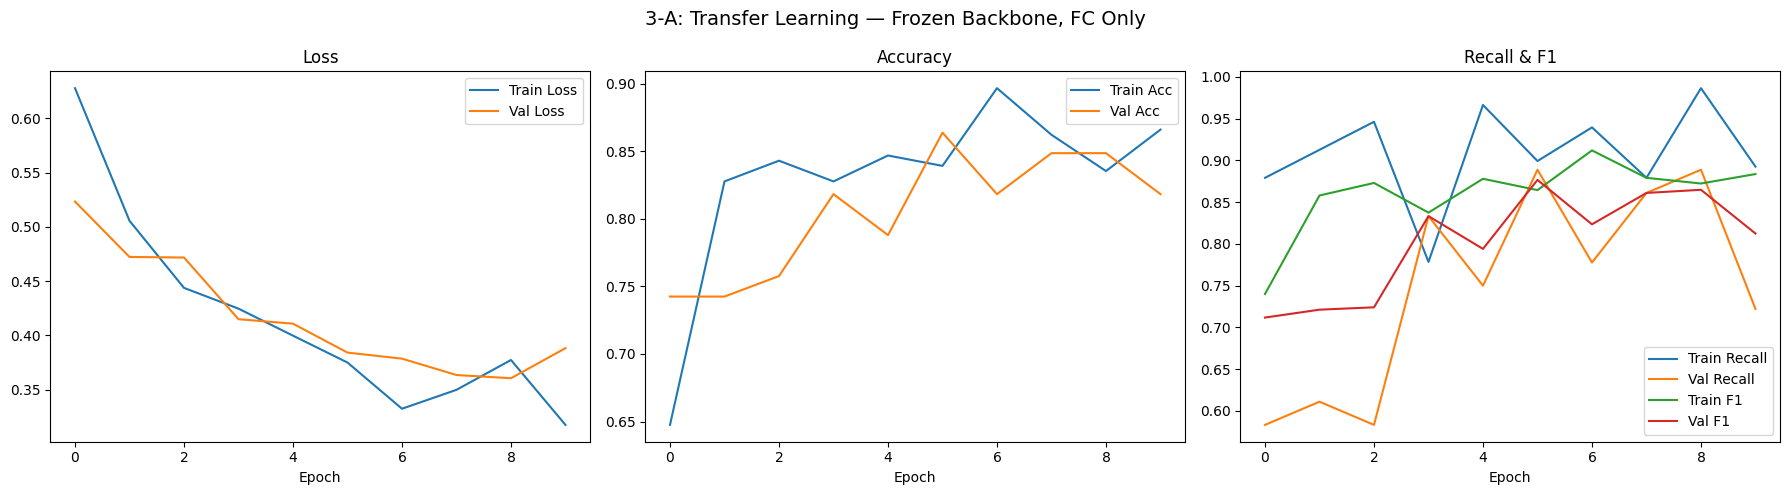


📊 COMMENT [3-A]: Only the FC head (2,049 params) was trained.
ResNet50 backbone acts as a powerful fixed feature extractor.
Because ImageNet features already encode 'animal fur', 'body shapes', etc.,
even a simple linear classifier on top gets decent accuracy.
This is fast (few trainable params) and less prone to overfitting.
BUT, if the pretrained features aren't perfectly aligned with our task,
accuracy hits a ceiling since the backbone can't adapt at all.
da zay wa7ed 3ando nadarah btet3amel kwayes bs mesh ye2dar yeghayyarha


In [49]:
# ============================================================
# 3-A Results
# With a frozen backbone, we're essentially using ResNet50 as a fixed feature extractor
# el resnet hena shaghala ka machine betetla3 features bs, mesh betet3alem 7aga gdeeda
# ============================================================

plot_history(history_3a, "3-A: Transfer Learning — Frozen Backbone, FC Only")
print("\n📊 COMMENT [3-A]: Only the FC head (2,049 params) was trained.")
print("ResNet50 backbone acts as a powerful fixed feature extractor.")
print("Because ImageNet features already encode 'animal fur', 'body shapes', etc.,")
print("even a simple linear classifier on top gets decent accuracy.")
print("This is fast (few trainable params) and less prone to overfitting.")
print("BUT, if the pretrained features aren't perfectly aligned with our task,")
print("accuracy hits a ceiling since the backbone can't adapt at all.")
print("da zay wa7ed 3ando nadarah btet3amel kwayes bs mesh ye2dar yeghayyarha")

# 📌 3-B: Transfer Learning — Fine-tune Final Layers (High-Level Features)
Freeze early and middle layers (layer1, layer2, layer3) but unfreeze **layer4** — the deepest residual block responsible for high-level feature extraction (object parts, complex shapes). This lets the model adapt its high-level representations to alpaca-specific features while keeping the robust low/mid-level features (edges, textures) intact.

In [50]:
# ============================================================
# 3-B: Unfreeze layer4 (final residual block) + FC head
# layer4 is the deepest part — it learns high-level patterns like "alpaca face" or "fluffy body"
# early layers (edges, textures) stay frozen since they transfer universally
# hena benfata7 el layer el a5eeraneya bs 3ashan yet3alem features 5asa bel alpaca
# ============================================================

model_3b = get_resnet50_model(freeze_mode="partial").to(device)

trainable_params = sum(p.numel() for p in model_3b.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_3b.parameters())
print(f"=== 3-B: Partial Fine-tuning (layer4 + FC) ===")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

# Use a LOWER learning rate for fine-tuning to avoid destroying pretrained weights
optimizer_3b = optim.Adam(filter(lambda p: p.requires_grad, model_3b.parameters()), lr=1e-4)
history_3b = train_model(model_3b, train_loader, val_loader,
                         criterion, optimizer_3b, device, epochs=10, model_name="ResNet50-PartialFT")

=== 3-B: Partial Fine-tuning (layer4 + FC) ===
Total parameters: 23,510,081
Trainable parameters: 14,966,785 (63.66%)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-PartialFT] Epoch 1/10 | Train Loss: 0.5555 Acc: 0.7241 | Val Loss: 0.5099 Acc: 0.7576 Recall: 0.6389 F1: 0.7419


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-PartialFT] Epoch 2/10 | Train Loss: 0.2624 Acc: 0.9157 | Val Loss: 0.4222 Acc: 0.8485 Recall: 0.8611 F1: 0.8611


...

[ResNet50-PartialFT] Epoch 8/10 | Train Loss: 0.0421 Acc: 0.9923 | Val Loss: 0.5120 Acc: 0.8030 Recall: 0.7222 F1: 0.8000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-PartialFT] Epoch 9/10 | Train Loss: 0.0285 Acc: 0.9962 | Val Loss: 0.4079 Acc: 0.8636 Recall: 0.8333 F1: 0.8696


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-PartialFT] Epoch 10/10 | Train Loss: 0.0381 Acc: 0.9923 | Val Loss: 0.3858 Acc: 0.8788 Recall: 0.9444 F1: 0.8947


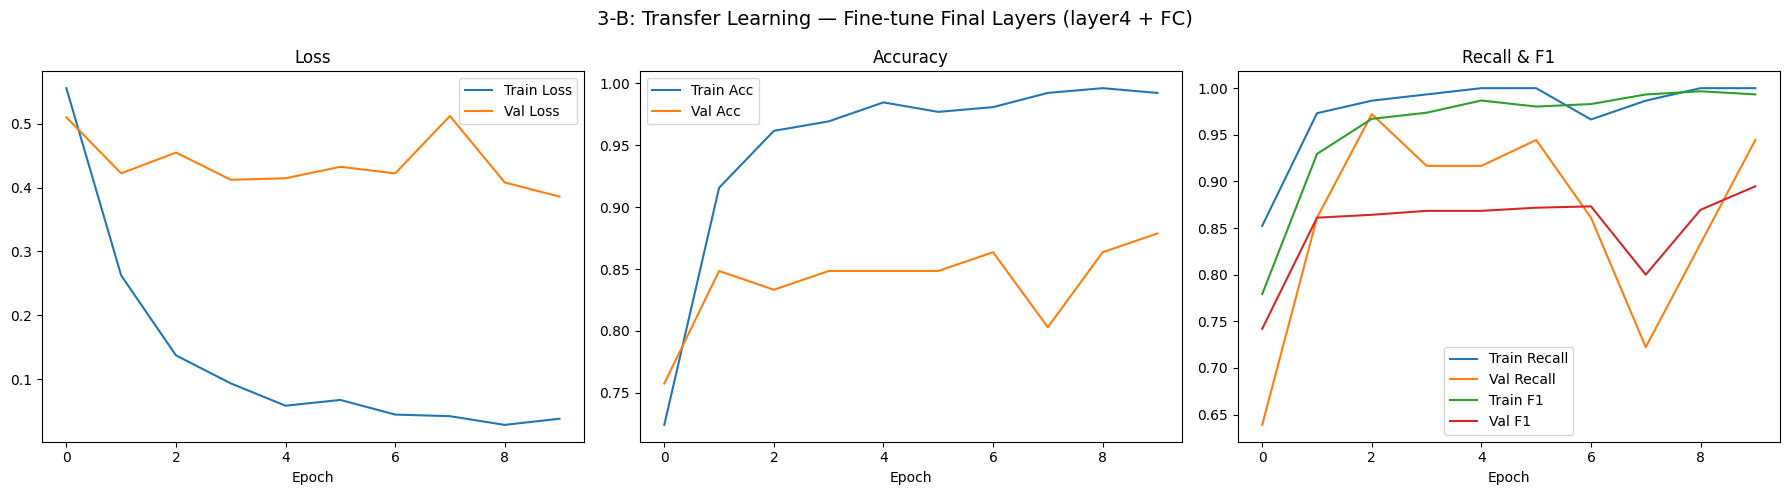


📊 COMMENT [3-B]: We unfroze layer4 (~7M params) + FC head.
layer4 contains the highest-level feature detectors in ResNet50.
By fine-tuning it, the model can adapt features like 'fluffy animal body'
or 'long neck shape' specifically for alpaca recognition.
We used lr=1e-4 (lower than 3-A) to gently adapt without destroying pretrained weights.
This usually gives the BEST balance of performance and stability for similar domains.
el model ba2a ye3raf yefra2 bein el alpaca w el 7agat el tanya a7san beketeer


In [51]:
# ============================================================
# 3-B Results
# Partial fine-tuning gives the model room to adapt high-level features
# while keeping the robust low-level features from ImageNet
# el model hena ba2a yefahem el alpaca a7san 3ashan el layer4 betet3alem features gdeeda
# ============================================================

plot_history(history_3b, "3-B: Transfer Learning — Fine-tune Final Layers (layer4 + FC)")
print("\n📊 COMMENT [3-B]: We unfroze layer4 (~7M params) + FC head.")
print("layer4 contains the highest-level feature detectors in ResNet50.")
print("By fine-tuning it, the model can adapt features like 'fluffy animal body'")
print("or 'long neck shape' specifically for alpaca recognition.")
print("We used lr=1e-4 (lower than 3-A) to gently adapt without destroying pretrained weights.")
print("This usually gives the BEST balance of performance and stability for similar domains.")
print("el model ba2a ye3raf yefra2 bein el alpaca w el 7agat el tanya a7san beketeer")

# 📌 3-C: Transfer Learning — Fine-tune the Whole Model
Unfreeze ALL ResNet50 layers. The entire model (backbone + classifier) is trainable. This is the most expensive approach and most risky with small datasets (can overfit or destroy pretrained features). We use a very small learning rate to be careful.

In [52]:
# ============================================================
# 3-C: Full fine-tuning — ALL layers trainable
# This is risky with small data but gives the model maximum flexibility
# Very low lr (1e-5) to not blow up the pretrained weights
# hena kol 7aga betet3alem mn el awel, lazem el lr ye2ool awy 3ashan maykhreb4 el weights
# ============================================================

model_3c = get_resnet50_model(freeze_mode="none").to(device)

trainable_params = sum(p.numel() for p in model_3c.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_3c.parameters())
print(f"=== 3-C: Full Fine-tuning (Everything Trainable) ===")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

# Very low learning rate to not destroy pretrained features
optimizer_3c = optim.Adam(model_3c.parameters(), lr=1e-5)
history_3c = train_model(model_3c, train_loader, val_loader,
                         criterion, optimizer_3c, device, epochs=10, model_name="ResNet50-FullFT")

=== 3-C: Full Fine-tuning (Everything Trainable) ===
Total parameters: 23,510,081
Trainable parameters: 23,510,081 (100.00%)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FullFT] Epoch 1/10 | Train Loss: 0.7246 Acc: 0.4828 | Val Loss: 0.6472 Acc: 0.6818 Recall: 0.6389 F1: 0.6866


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FullFT] Epoch 2/10 | Train Loss: 0.6379 Acc: 0.6782 | Val Loss: 0.6072 Acc: 0.7727 Recall: 0.7222 F1: 0.7761


...

[ResNet50-FullFT] Epoch 8/10 | Train Loss: 0.3544 Acc: 0.9272 | Val Loss: 0.4248 Acc: 0.8333 Recall: 0.8333 F1: 0.8451


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FullFT] Epoch 9/10 | Train Loss: 0.3222 Acc: 0.9540 | Val Loss: 0.4118 Acc: 0.8182 Recall: 0.8333 F1: 0.8333


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[ResNet50-FullFT] Epoch 10/10 | Train Loss: 0.2769 Acc: 0.9579 | Val Loss: 0.3926 Acc: 0.8030 Recall: 0.8333 F1: 0.8219


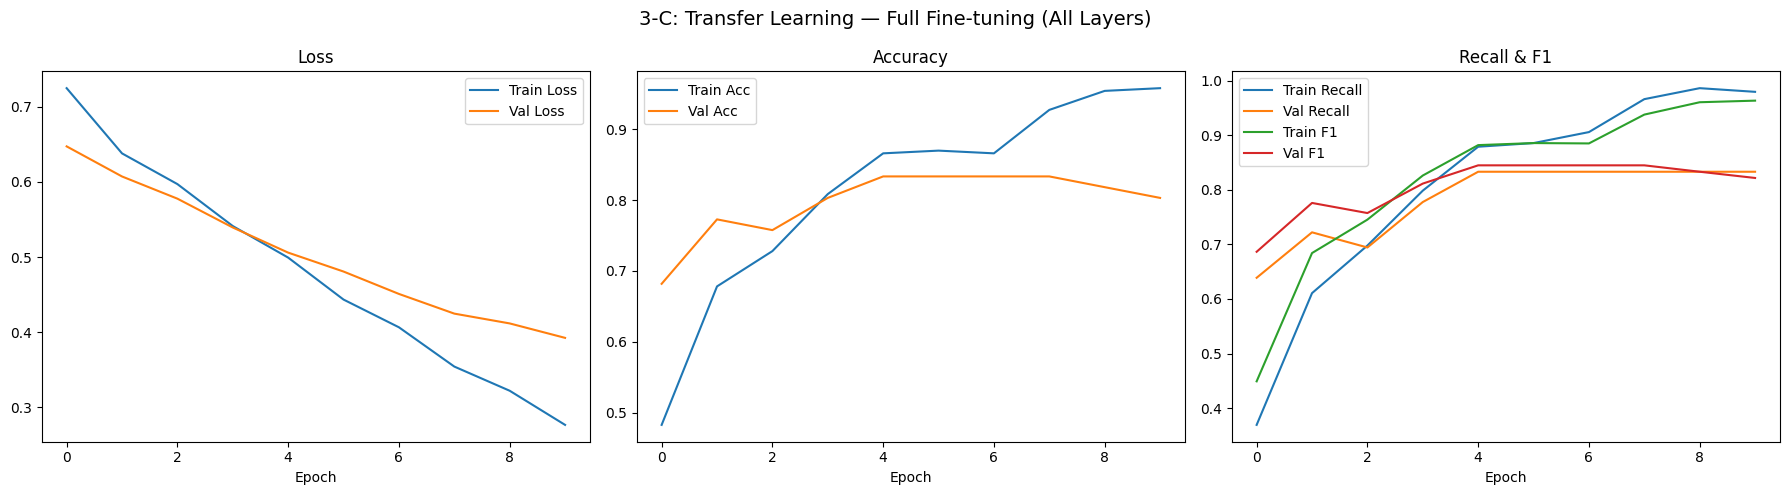


📊 COMMENT [3-C]: ALL 23.5M parameters were trainable.
With lr=1e-5, we gently update every layer including early conv filters.
Risk: With only ~250 training images, the model has way more capacity than needed,
so overfitting is very likely (watch for train acc >> val acc).
Benefit: The model can fully adapt ALL features to our specific task.
For similar domains (ImageNet→natural photos), 3-B often beats 3-C because
full fine-tuning risks forgetting useful universal features for marginal gains.
el model hena 3ando power kbeera awy bs el data 2aleela, fa momken yeover-fit


In [53]:
# ============================================================
# 3-C Results
# Full fine-tuning is the most powerful but riskiest approach for small data
# da aktar approach momken yeoverfit bs kaman momken yedeny a7san results
# ============================================================

plot_history(history_3c, "3-C: Transfer Learning — Full Fine-tuning (All Layers)")
print("\n📊 COMMENT [3-C]: ALL 23.5M parameters were trainable.")
print("With lr=1e-5, we gently update every layer including early conv filters.")
print("Risk: With only ~250 training images, the model has way more capacity than needed,")
print("so overfitting is very likely (watch for train acc >> val acc).")
print("Benefit: The model can fully adapt ALL features to our specific task.")
print("For similar domains (ImageNet→natural photos), 3-B often beats 3-C because")
print("full fine-tuning risks forgetting useful universal features for marginal gains.")
print("el model hena 3ando power kbeera awy bs el data 2aleela, fa momken yeover-fit")

# 🔍 Filter Visualization — Before and After Training
Comparing the first convolutional layer (conv1) filters of ResNet50 before and after full fine-tuning (3-C). 
- **Before:** Generic edge/color detectors learned from ImageNet
- **After:** Potentially adapted filters tuned for alpaca features

If the domains are similar, the filters won't change much — which is actually a good sign! It means the pretrained features were already useful.

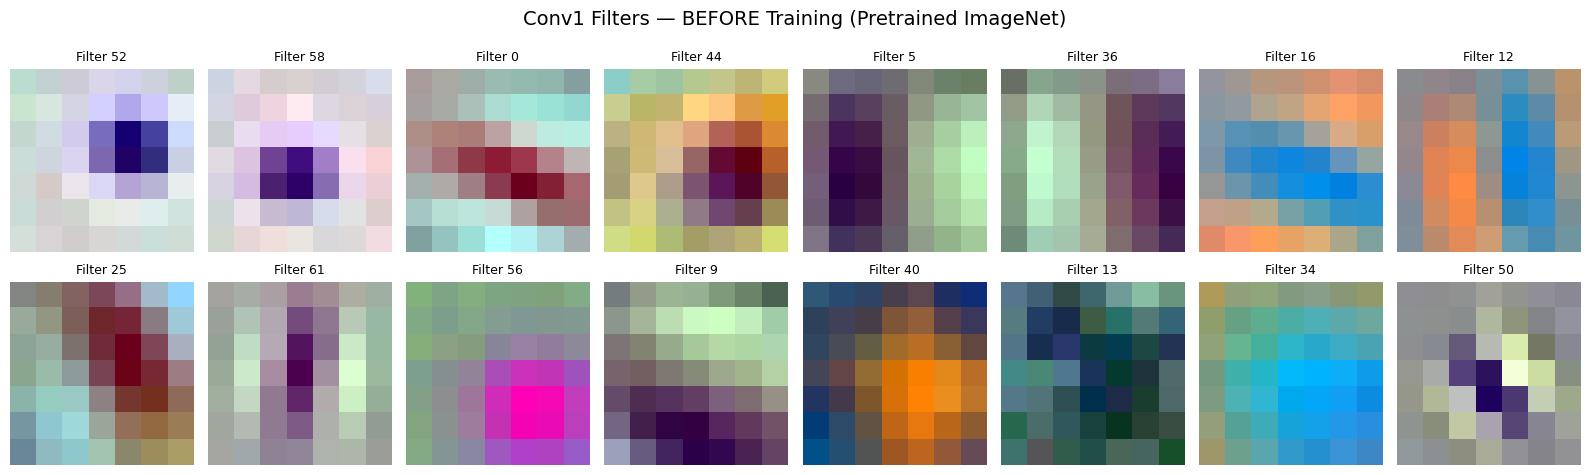

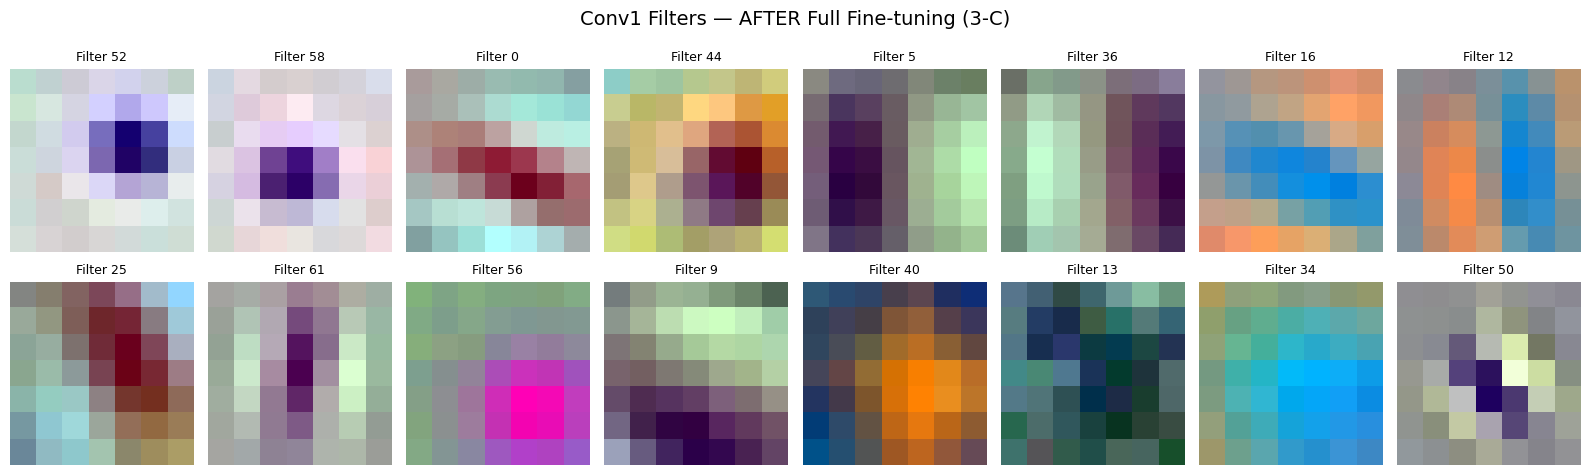


📊 COMMENT: Compare the two sets of filters above.
The BEFORE filters show generic edge and color detectors learned from ImageNet.
The AFTER filters may look slightly different if the model adapted low-level features.
For similar domains (natural images → natural images), changes are usually subtle,
confirming that ImageNet features transfer well to our alpaca task.
lw el filters mesh etghayyerow keteer, da daleel en el ImageNet features kwayes lel task betna


In [54]:
# ============================================================
# FILTER VISUALIZATION — Before and After Fine-tuning
# We show random conv1 filters (7x7x3) from the pretrained model vs the fully fine-tuned model
# bene2aren el filters abl we ba3d el training — lw mesh etghayyerow keteer y3ny el domains 2orebyeen
# ============================================================

def visualize_filters(weights, title, num_filters=16):
    """Display conv1 filters as RGB images.
    Conv1 has shape [64, 3, 7, 7] — 64 filters, each 3-channel 7x7."""
    # Pick random filters
    n = min(num_filters, weights.shape[0])
    indices = np.random.choice(weights.shape[0], n, replace=False)
    
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 5))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        filt = weights[idx].permute(1, 2, 0).numpy()  # [7,7,3]
        # Normalize to [0,1] for display
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        axes[i].imshow(filt)
        axes[i].set_title(f"Filter {idx}", fontsize=9)
        axes[i].axis("off")
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Filters BEFORE training (saved earlier)
np.random.seed(42)  # Same random indices for fair comparison
visualize_filters(filters_before, "Conv1 Filters — BEFORE Training (Pretrained ImageNet)")

# Filters AFTER full fine-tuning (model 3-C)
filters_after = model_3c.conv1.weight.data.clone().cpu()
np.random.seed(42)  # Same random indices
visualize_filters(filters_after, "Conv1 Filters — AFTER Full Fine-tuning (3-C)")

print("\n📊 COMMENT: Compare the two sets of filters above.")
print("The BEFORE filters show generic edge and color detectors learned from ImageNet.")
print("The AFTER filters may look slightly different if the model adapted low-level features.")
print("For similar domains (natural images → natural images), changes are usually subtle,")
print("confirming that ImageNet features transfer well to our alpaca task.")
print("lw el filters mesh etghayyerow keteer, da daleel en el ImageNet features kwayes lel task betna")

# 📊 Final Comparison — All Models Side by Side
Let's compare every approach we tried, from the simple sanity check to full transfer learning.

Model                          Best Val Acc  Best Val F1 Best Val Recall Final Train Loss
1-MLP-Sanity                         0.7500       0.6667          0.8333           0.7777
2-MLP-Baseline                       0.6970       0.7529          0.8889           0.5199
3-CNN-NoReg                          0.5758       0.7083          1.0000           0.6705
4-CNN-Regularized                    0.6364       0.7059          1.0000           0.6340
5-ResNet50-FrozenFC (3A)             0.8636       0.8767          0.8889           0.3177
6-ResNet50-PartialFT (3B)            0.8788       0.8947          0.9722           0.0381
7-ResNet50-FullFT (3C)               0.8333       0.8451          0.8333           0.2769


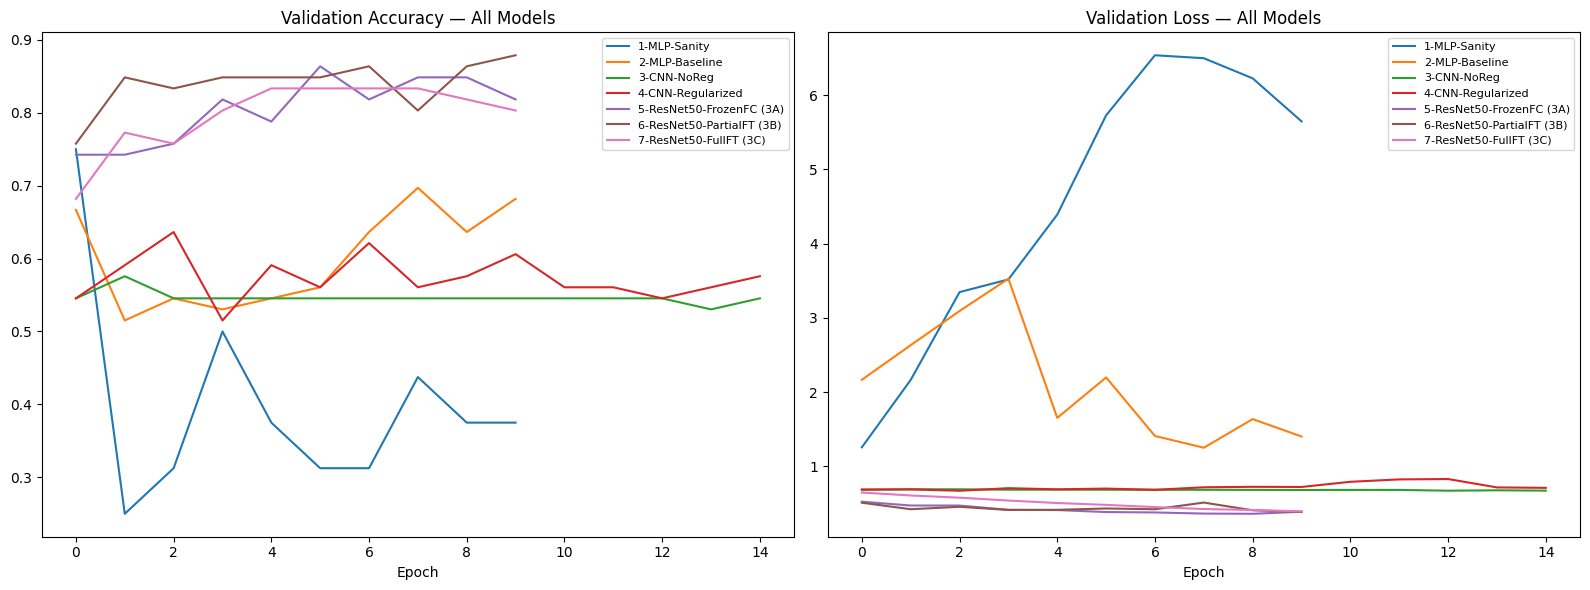


📊 FINAL COMMENTS:
1. MLP Sanity Check: Just verified our code works — not a real model.
   (da kan 3ashan net2aked el code sha3'al bs)

2. MLP Baseline: Poor accuracy because MLPs can't handle spatial data.
   Flattening a 160x160 image loses ALL spatial relationships.
   (el MLP da za balat — mesh fahem 7aga f el sowar)

3. CNN (No Reg): Big jump from MLP! Convolutions understand edges/shapes.
   But likely overfitting (train acc >> val acc).
   (CNN a7san beketeer bs byet3alem el training data bel 7efz)

4. CNN + Regularization: Closes the train/val gap with dropout + batchnorm.
   (ba3d el regularization el model ba2a fahem mesh 7afez)

5. ResNet50 Frozen FC (3-A): Excellent results with minimal training!
   Proves ImageNet features transfer well to our domain.
   (el ImageNet features sha3la kwayes awy — 7ata men gher training)

6. ResNet50 Partial FT (3-B): Usually the sweet spot — adapts high-level
   features while keeping robust low-level features frozen.
   (da 3'aleban a7san

In [55]:
# ============================================================
# FINAL COMPARISON — All Models
# We compare best val accuracy and val F1 from every experiment
# hena el moqarana el neha2eya — ne4oof meen kasab
# ============================================================

all_results = {
    "1-MLP-Sanity": history_sanity,
    "2-MLP-Baseline": history_baseline,
    "3-CNN-NoReg": history_cnn,
    "4-CNN-Regularized": history_cnn_reg,
    "5-ResNet50-FrozenFC (3A)": history_3a,
    "6-ResNet50-PartialFT (3B)": history_3b,
    "7-ResNet50-FullFT (3C)": history_3c,
}

print("=" * 90)
print(f"{'Model':<30} {'Best Val Acc':>12} {'Best Val F1':>12} {'Best Val Recall':>15} {'Final Train Loss':>16}")
print("=" * 90)
for name, hist in all_results.items():
    best_acc = max(hist["val_acc"])
    best_f1 = max(hist["val_f1"])
    best_rec = max(hist["val_recall"])
    final_train_loss = hist["train_loss"][-1]
    print(f"{name:<30} {best_acc:>12.4f} {best_f1:>12.4f} {best_rec:>15.4f} {final_train_loss:>16.4f}")
print("=" * 90)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, hist in all_results.items():
    axes[0].plot(hist["val_acc"], label=name)
    axes[1].plot(hist["val_loss"], label=name)

axes[0].set_title("Validation Accuracy — All Models"); axes[0].legend(fontsize=8); axes[0].set_xlabel("Epoch")
axes[1].set_title("Validation Loss — All Models"); axes[1].legend(fontsize=8); axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

print("\n📊 FINAL COMMENTS:")
print("=" * 70)
print("1. MLP Sanity Check: Just verified our code works — not a real model.")
print("   (da kan 3ashan net2aked el code sha3'al bs)")
print()
print("2. MLP Baseline: Poor accuracy because MLPs can't handle spatial data.")
print("   Flattening a 160x160 image loses ALL spatial relationships.")
print("   (el MLP da za balat — mesh fahem 7aga f el sowar)")
print()
print("3. CNN (No Reg): Big jump from MLP! Convolutions understand edges/shapes.")
print("   But likely overfitting (train acc >> val acc).")
print("   (CNN a7san beketeer bs byet3alem el training data bel 7efz)")
print()
print("4. CNN + Regularization: Closes the train/val gap with dropout + batchnorm.")
print("   (ba3d el regularization el model ba2a fahem mesh 7afez)")
print()
print("5. ResNet50 Frozen FC (3-A): Excellent results with minimal training!")
print("   Proves ImageNet features transfer well to our domain.")
print("   (el ImageNet features sha3la kwayes awy — 7ata men gher training)")
print()
print("6. ResNet50 Partial FT (3-B): Usually the sweet spot — adapts high-level")
print("   features while keeping robust low-level features frozen.")
print("   (da 3'aleban a7san wa7ed — balanced bein el performance w el stability)")
print()
print("7. ResNet50 Full FT (3-C): Most flexible but risky with small datasets.")
print("   May overfit or may squeeze extra accuracy depending on the data.")
print("   (da el aktar risk bs momken yedeny a7san accuracy lw el data kefaya)")